# 🥋 Poser — Advanced Exploratory Data Analysis
**Dataset:** `karate_normalized_base.csv`  
**Classes:** GedanBarai · Gyakudzuki · MaeGeri  
**Architecture:** Translation-invariant (Mid-Hip origin) + Scale-invariant (÷ shoulder width)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Aesthetics ──────────────────────────────────────────────────────────────
plt.style.use('dark_background')
PALETTE   = {'GedanBarai': '#00C9FF', 'Gyakudzuki': '#FF6B6B', 'MaeGeri': '#A8FF78'}
BG_COLOR  = '#0D1117'
GRID_CLR  = '#21262D'
sns.set_theme(style='darkgrid', rc={'figure.facecolor': BG_COLOR, 'axes.facecolor': '#161B22'})

# ── Load Data ───────────────────────────────────────────────────────────────
CSV_PATH = r"D:\CS-Senior26'\GR\martial-arts-trainer\backend\app\data\karate_normalized_base.csv"
df = pd.read_csv(CSV_PATH)
print(f'✅ Loaded  →  {df.shape[0]:,} rows  ×  {df.shape[1]} columns')
df.head(3)

✅ Loaded  →  10,740 rows  ×  149 columns


,folder_label,clip_id,frame_idx,angle_00,angle_01,angle_02,angle_03,angle_04,angle_05,angle_06,...,z30,v30,x31,y31,z31,v31,x32,y32,z32,v32
0,GedanBarai,GedanBarai_front_003_0007,1,0.952870,0.904945,0.964732,0.979894,0.525254,0.536842,0.933171,...,1.768412,0.926285,0.633223,4.544224,0.471246,0.986608,-0.689517,4.499623,0.326759,0.991978
1,GedanBarai,GedanBarai_front_003_0007,2,0.947708,0.908403,0.966056,0.977355,0.530493,0.530824,0.935368,...,1.824032,0.929003,0.619588,4.526525,0.651605,0.987074,-0.694402,4.502203,0.381781,0.992248
2,GedanBarai,GedanBarai_front_003_0007,3,0.943221,0.902319,0.966425,0.973595,0.533802,0.527669,0.936819,...,1.858642,0.933365,0.617341,4.512970,0.672001,0.987698,-0.700596,4.503754,0.405308,0.992689


## § 1 — Clip-Level Class Balance
We count **unique `clip_id`s** per class — NOT total frame rows — to understand the true data distribution.

=== Clip-Level Class Balance ===
folder_label  num_clips
  GedanBarai        133
     MaeGeri        119
  Gyakudzuki        106

Total unique clips: 358


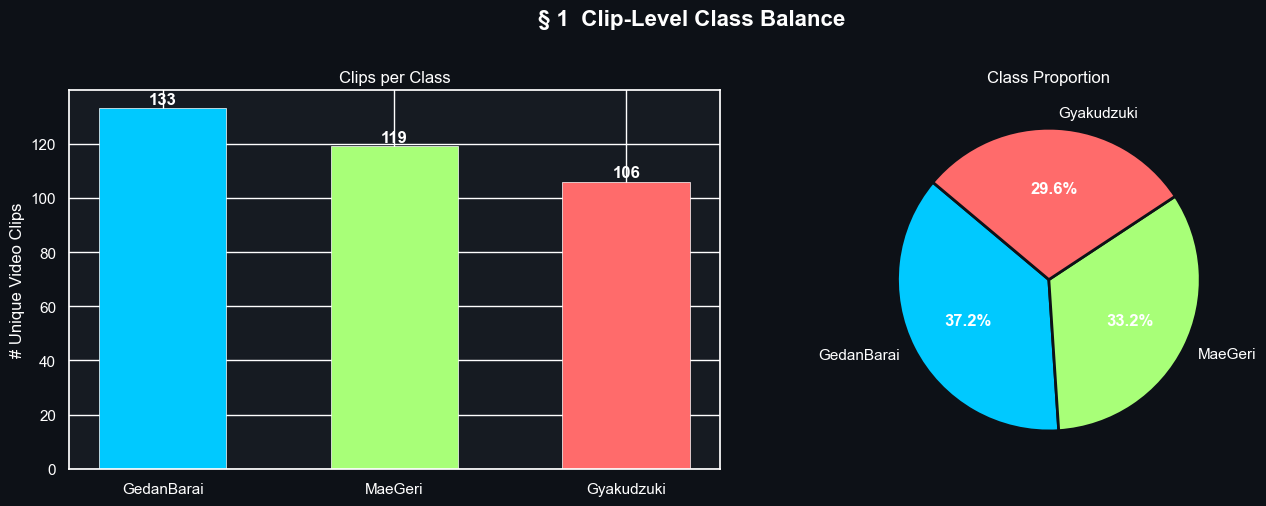


⚠️  Balance Assessment: BALANCED ✅


In [2]:
clip_balance = (
    df.drop_duplicates(subset=['clip_id'])
      .groupby('folder_label')['clip_id']
      .count()
      .reset_index()
      .rename(columns={'clip_id': 'num_clips'})
      .sort_values('num_clips', ascending=False)
)
print('=== Clip-Level Class Balance ===')
print(clip_balance.to_string(index=False))
total_clips  = clip_balance['num_clips'].sum()
clip_balance['pct'] = (clip_balance['num_clips'] / total_clips * 100).round(1)
print(f'\nTotal unique clips: {total_clips}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=BG_COLOR)
fig.suptitle('§ 1  Clip-Level Class Balance', fontsize=16, fontweight='bold', color='white', y=1.01)

colors = [PALETTE[lbl] for lbl in clip_balance['folder_label']]

# Bar chart
bars = axes[0].bar(clip_balance['folder_label'], clip_balance['num_clips'],
                   color=colors, edgecolor='white', linewidth=0.5, width=0.55)
axes[0].set_title('Clips per Class', color='white')
axes[0].set_ylabel('# Unique Video Clips', color='white')
axes[0].tick_params(colors='white')
for bar, val in zip(bars, clip_balance['num_clips']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 str(val), ha='center', va='bottom', color='white', fontweight='bold')

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    clip_balance['num_clips'],
    labels=clip_balance['folder_label'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=140,
    textprops={'color': 'white'},
    wedgeprops={'edgecolor': BG_COLOR, 'linewidth': 2}
)
for at in autotexts:
    at.set_fontweight('bold')
axes[1].set_title('Class Proportion', color='white')

plt.tight_layout()
plt.savefig('sec1_class_balance.png', dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()
print('\n⚠️  Balance Assessment:', 'BALANCED ✅' if clip_balance['num_clips'].std() / clip_balance['num_clips'].mean() < 0.15 else 'IMBALANCED ⚠️ — consider class weighting')

## § 2 — Missing / Infinite Value Check

In [3]:
print('=== Missing Values ===')
missing = df.isnull().sum()
missing_cols = missing[missing > 0]
if missing_cols.empty:
    print('✅ No missing values found!')
else:
    print(missing_cols)

print('\n=== Infinite Values ===')
num_df = df.select_dtypes(include=[np.number])
inf_mask = np.isinf(num_df)
inf_cols = inf_mask.sum()
inf_cols = inf_cols[inf_cols > 0]
if inf_cols.empty:
    print('✅ No infinite values found!')
else:
    print(inf_cols)

print('\n=== Basic Statistics (feature columns) ===')
print(num_df.describe().round(4))

print('\n=== Frame Count Validation ===')
frames_per_clip = df.groupby('clip_id')['frame_idx'].count()
print(f'Expected 30 frames per clip: {(frames_per_clip == 30).all()}')
if not (frames_per_clip == 30).all():
    bad = frames_per_clip[frames_per_clip != 30]
    print(f'⚠️ Clips with wrong frame count:\n{bad}')

=== Missing Values ===
✅ No missing values found!

=== Infinite Values ===
✅ No infinite values found!

=== Basic Statistics (feature columns) ===
        frame_idx    angle_00    angle_01    angle_02    angle_03    angle_04  \
count  10740.0000  10740.0000  10740.0000  10740.0000  10740.0000  10740.0000   
mean      15.5000      0.8203      0.8215      0.8933      0.8911      0.5617   
std        8.6558      0.1376      0.1286      0.1566      0.1445      0.1153   
min        1.0000      0.0019      0.0021      0.0006      0.0004      0.0006   
25%        8.0000      0.7210      0.7214      0.8659      0.8416      0.5058   
50%       15.5000      0.8413      0.8423      0.9494      0.9474      0.5569   
75%       23.0000      0.9339      0.9316      0.9812      0.9797      0.6197   
max       30.0000      0.9997      0.9997      0.9998      0.9998      0.9996   

         angle_05    angle_06    angle_07    angle_08  ...         z30  \
count  10740.0000  10740.0000  10740.0000  10740.

## § 3 — Upper vs Lower Body Feature Variance (Violin Plots)
This is the core diagnostic: do upper-body features vary **between classes** more than lower-body ones?  
If so, the Dual-Stem architecture is justified.

Upper features: 54  |  Lower features: 48

=== EXACT NUMERICAL VARIANCE ===
                           median       mean         max        std
track      folder_label                                            
Lower Body GedanBarai    1.959427  22.101765  588.785212  78.642642
           Gyakudzuki    0.739836  12.438101  311.466037  37.269243
           MaeGeri       1.463431  25.494984  654.987624  76.426675
Upper Body GedanBarai    1.760241  14.622354  408.686713  44.845758
           Gyakudzuki    3.402605  17.778735  376.643805  49.630809
           MaeGeri       0.450309  20.103094  930.725887  91.238094


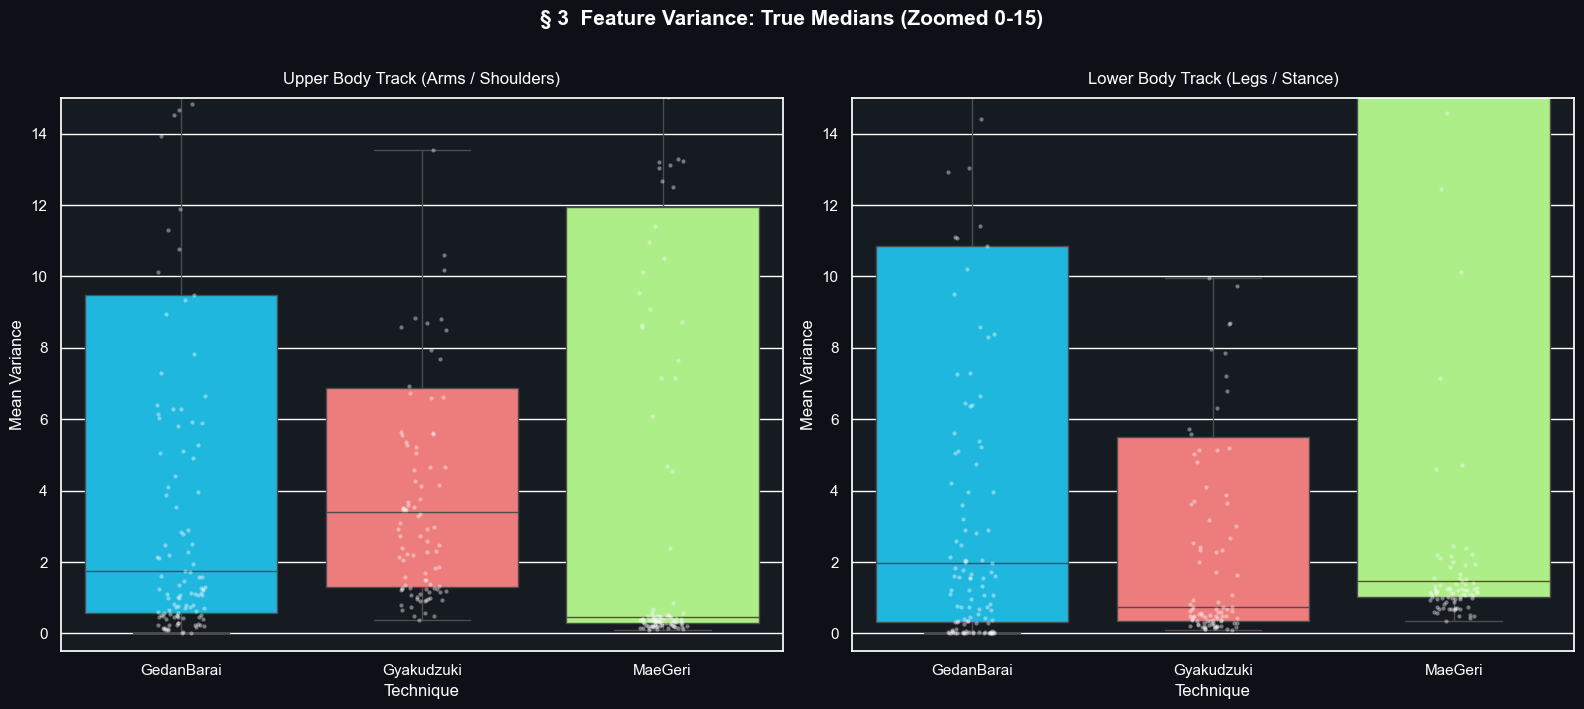

In [6]:
# ── Define feature groups ────────────────────────────────────────────────────
UPPER_COORDS = [f'{c}{i}' for i in range(11, 23) for c in ['x', 'y', 'z', 'v']]
UPPER_ANGLES = [f'angle_{i:02d}' for i in range(8, 14)]
UPPER_FEATS  = UPPER_COORDS + UPPER_ANGLES   # 48 + 6 = 54

LOWER_COORDS = [f'{c}{i}' for i in range(23, 33) for c in ['x', 'y', 'z', 'v']]
LOWER_ANGLES = [f'angle_{i:02d}' for i in range(0, 8)]
LOWER_FEATS  = LOWER_COORDS + LOWER_ANGLES   # 40 + 8 = 48

print(f'Upper features: {len(UPPER_FEATS)}  |  Lower features: {len(LOWER_FEATS)}')

# ── Compute per-clip VARIANCE for each feature, then average ──────────────
def clip_variance_df(feature_list, label):
    rows = []
    for clip, grp in df.groupby('clip_id'):
        cls = grp['folder_label'].iloc[0]
        var = grp[feature_list].var().mean()   # mean variance across features
        rows.append({'clip_id': clip, 'folder_label': cls, 'mean_variance': var, 'track': label})
    return pd.DataFrame(rows)

upper_var = clip_variance_df(UPPER_FEATS, 'Upper Body')
lower_var = clip_variance_df(LOWER_FEATS, 'Lower Body')
combined  = pd.concat([upper_var, lower_var], ignore_index=True)

# ── Numerical Proof of Variance ──────────────────────────────────────────────
print('\n=== EXACT NUMERICAL VARIANCE ===')
variance_summary = combined.groupby(['track', 'folder_label'])['mean_variance'].agg(['median', 'mean', 'max', 'std'])
print(variance_summary)

# ── Plot: The Truth About Variance (Zoomed-In Boxplot) ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor=BG_COLOR)
fig.suptitle('§ 3  Feature Variance: True Medians (Zoomed 0-15)',
             fontsize=15, fontweight='bold', color='white', y=1.01)

for ax, track, title in zip(axes, ['Upper Body', 'Lower Body'],
                             ['Upper Body Track (Arms / Shoulders)', 'Lower Body Track (Legs / Stance)']):
    data = combined[combined['track'] == track]
    
    # Boxplot shows the exact median line and quartiles, no KDE distortion
    sns.boxplot(
        data=data, x='folder_label', y='mean_variance',
        palette=PALETTE, ax=ax, showfliers=False, # We hide extreme outliers from the box calculation
        order=['GedanBarai', 'Gyakudzuki', 'MaeGeri']
    )
    
    # Overlay the actual data points
    sns.stripplot(
        data=data, x='folder_label', y='mean_variance',
        color='white', alpha=0.4, size=3, jitter=True, ax=ax,
        order=['GedanBarai', 'Gyakudzuki', 'MaeGeri']
    )
    
    ax.set_title(title, color='white', fontsize=12, pad=10)
    ax.set_xlabel('Technique', color='white')
    ax.set_ylabel('Mean Variance', color='white')
    ax.tick_params(colors='white')
    
    # CRITICAL: Zoom in on the Y-axis to see the medians clearly!
    ax.set_ylim(-0.5, 15)

plt.tight_layout()
plt.savefig('sec3_variance_boxplot_zoomed.png', dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

In [5]:
# ── Numerical Proof of Variance ──────────────────────────────────────────────
print('\n=== EXACT NUMERICAL VARIANCE ===')
variance_summary = combined.groupby(['track', 'folder_label'])['mean_variance'].agg(['median', 'mean', 'max', 'std'])
print(variance_summary)

print('\n=== VARIANCE RATIOS ===')
lower_data = combined[combined['track'] == 'Lower Body']
mae_median = lower_data[lower_data['folder_label'] == 'MaeGeri']['mean_variance'].median()
gedan_median = lower_data[lower_data['folder_label'] == 'GedanBarai']['mean_variance'].median()

print(f"MaeGeri Lower Body Median Variance is {mae_median / gedan_median:.2f}x higher than GedanBarai.")


=== EXACT NUMERICAL VARIANCE ===
                           median       mean         max        std
track      folder_label                                            
Lower Body GedanBarai    1.959427  22.101765  588.785212  78.642642
           Gyakudzuki    0.739836  12.438101  311.466037  37.269243
           MaeGeri       1.463431  25.494984  654.987624  76.426675
Upper Body GedanBarai    1.760241  14.622354  408.686713  44.845758
           Gyakudzuki    3.402605  17.778735  376.643805  49.630809
           MaeGeri       0.450309  20.103094  930.725887  91.238094

=== VARIANCE RATIOS ===
MaeGeri Lower Body Median Variance is 0.75x higher than GedanBarai.


## § 4 — Angle Feature Distribution & Correlation Heatmap
Correlation of all **14 angle features** — identifies redundancy and informs attention heads.

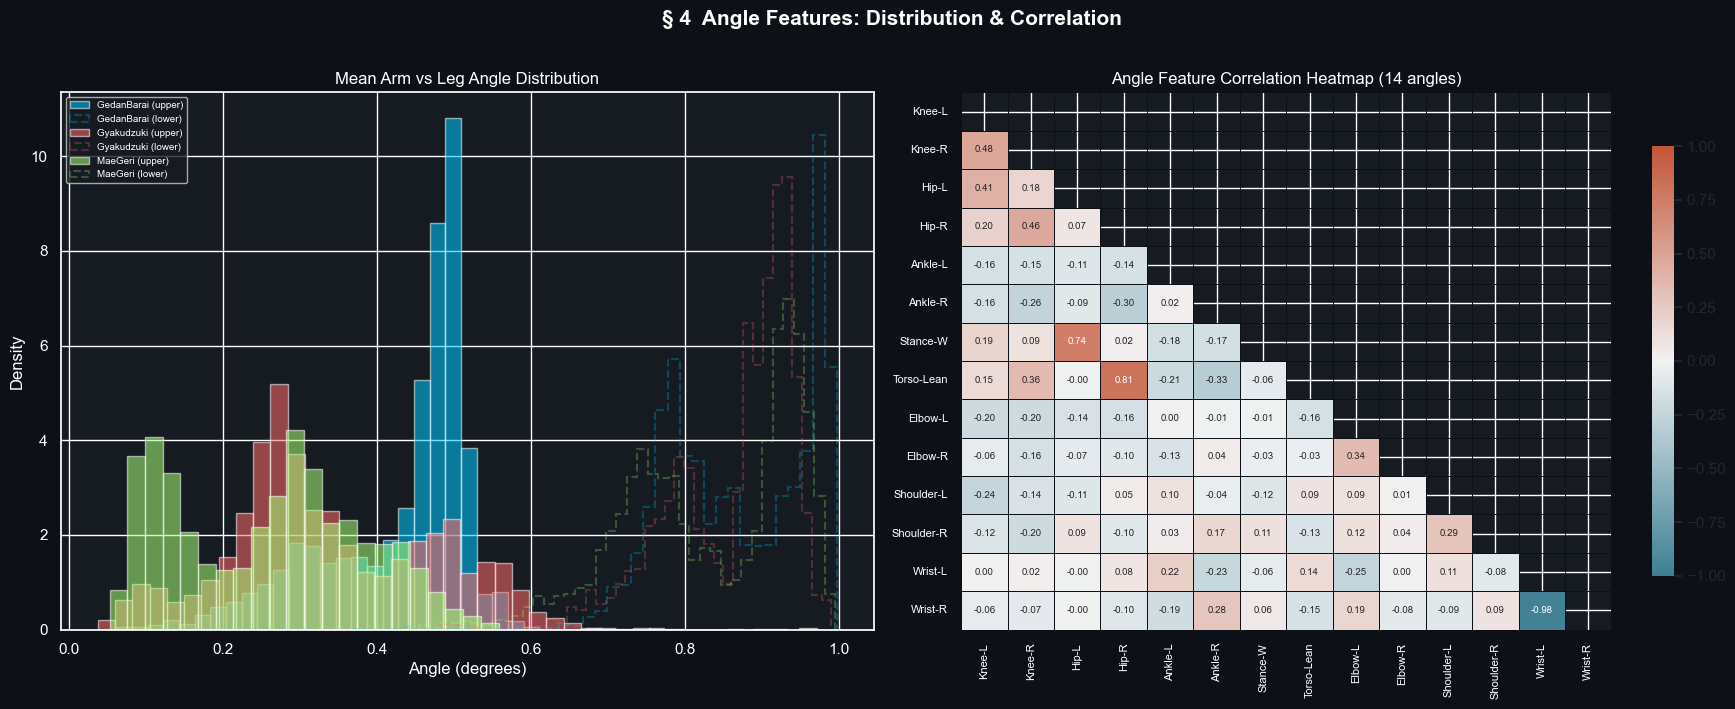


🔗 High-correlation angle pairs (|r| > 0.7):
Wrist-R     Wrist-L    0.975248
Torso-Lean  Hip-R      0.809831
Stance-W    Hip-L      0.744047
dtype: float64


In [11]:
ALL_ANGLES = [f'angle_{i:02d}' for i in range(14)]
angle_labels = {
    'angle_00': 'Knee-L',  'angle_01': 'Knee-R',
    'angle_02': 'Hip-L',   'angle_03': 'Hip-R',
    'angle_04': 'Ankle-L', 'angle_05': 'Ankle-R',
    'angle_06': 'Stance-W','angle_07': 'Torso-Lean',
    'angle_08': 'Elbow-L', 'angle_09': 'Elbow-R',
    'angle_10': 'Shoulder-L','angle_11':'Shoulder-R',
    'angle_12': 'Wrist-L', 'angle_13': 'Wrist-R'
}

angle_df = df[ALL_ANGLES].copy().rename(columns=angle_labels)
corr = angle_df.corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 7), facecolor=BG_COLOR)
fig.suptitle('§ 4  Angle Features: Distribution & Correlation', fontsize=15,
             fontweight='bold', color='white', y=1.01)

# ─ KDE distributions per class ──────────────────────────────────────────────
for cls, clr in PALETTE.items():
    sub = df[df['folder_label'] == cls]
    # plot mean of elbow angles as representative
    mean_upper = sub[['angle_08','angle_09','angle_10','angle_11']].mean(axis=1)
    mean_lower = sub[['angle_00','angle_01','angle_02','angle_03']].mean(axis=1)
    axes[0].hist(mean_upper, bins=40, alpha=0.55, color=clr, label=f'{cls} (upper)', density=True)
    axes[0].hist(mean_lower, bins=40, alpha=0.25, color=clr, label=f'{cls} (lower)', density=True, linestyle='dashed', histtype='step', linewidth=1.5)
axes[0].set_title('Mean Arm vs Leg Angle Distribution', color='white')
axes[0].set_xlabel('Angle (degrees)', color='white')
axes[0].set_ylabel('Density', color='white')
axes[0].tick_params(colors='white')
axes[0].legend(fontsize=7, facecolor='#161B22', labelcolor='white')

# ─ Heatmap ──────────────────────────────────────────────────────────────────
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(220, 20, as_cmap=True)
sns.heatmap(
    corr, mask=mask, cmap=cmap, vmax=1.0, vmin=-1.0,
    center=0, annot=True, fmt='.2f', linewidths=0.4,
    linecolor='#0D1117', ax=axes[1],
    annot_kws={'size': 7}, cbar_kws={'shrink': 0.8}
)
axes[1].set_title('Angle Feature Correlation Heatmap (14 angles)', color='white')
axes[1].tick_params(colors='white', labelsize=8)

plt.tight_layout()
plt.savefig('sec4_angle_distributions.png', dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

# High-correlation pairs
print('\n🔗 High-correlation angle pairs (|r| > 0.7):')
corr_pairs = corr.abs().unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1.0]  # remove self-correlations
high = corr_pairs[corr_pairs > 0.7].drop_duplicates()
print(high.head(10) if not high.empty else '   None found — angles are well-decorrelated ✅')

## § 5 — Per-Class Temporal Trajectory
How do key angles evolve over the 30-frame clip window?

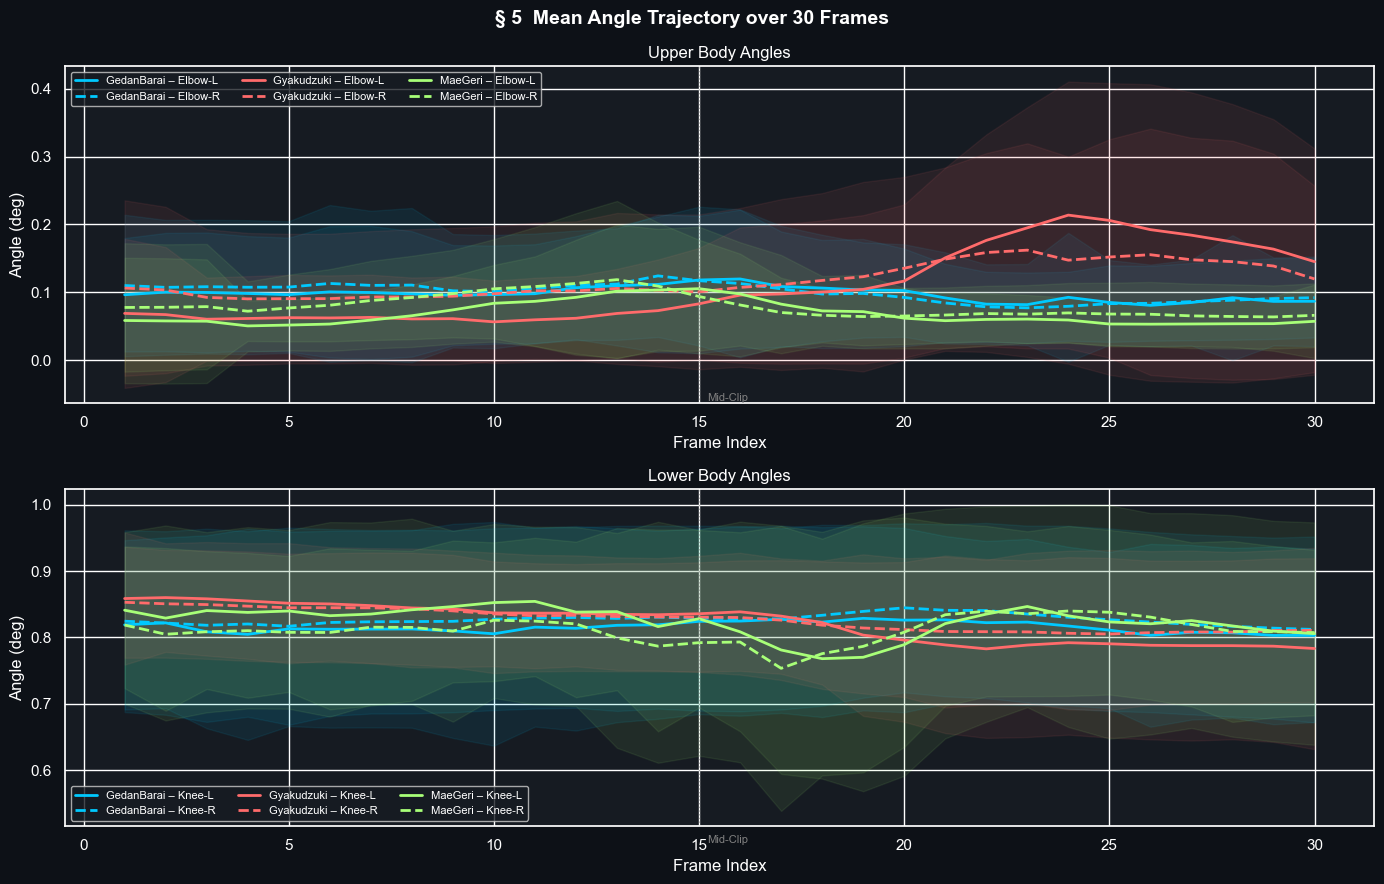

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), facecolor=BG_COLOR)
fig.suptitle('§ 5  Mean Angle Trajectory over 30 Frames', fontsize=14, fontweight='bold', color='white')

representative = {'Upper': ['angle_08','angle_09'], 'Lower': ['angle_00','angle_01']}

for ax, (track, angles) in zip(axes, representative.items()):
    for cls, clr in PALETTE.items():
        sub = df[df['folder_label'] == cls]
        for a, ls in zip(angles, ['-', '--']):
            mean_traj = sub.groupby('frame_idx')[a].mean()
            std_traj  = sub.groupby('frame_idx')[a].std()
            frames    = mean_traj.index
            ax.plot(frames, mean_traj, color=clr, linestyle=ls, linewidth=2,
                    label=f'{cls} – {angle_labels.get(a, a)}')
            ax.fill_between(frames, mean_traj - std_traj, mean_traj + std_traj,
                            color=clr, alpha=0.08)
    ax.set_title(f'{track} Body Angles', color='white')
    ax.set_xlabel('Frame Index', color='white')
    ax.set_ylabel('Angle (deg)', color='white')
    ax.tick_params(colors='white')
    ax.legend(fontsize=8, facecolor='#161B22', labelcolor='white', ncol=3)
    ax.axvline(x=15, color='gray', linestyle=':', linewidth=1, alpha=0.6)
    ax.text(15.2, ax.get_ylim()[0]*0.95, 'Mid-Clip', color='gray', fontsize=8)

plt.tight_layout()
plt.savefig('sec5_temporal_trajectory.png', dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

## § 6 — Summary & Readiness Report

In [13]:
print('=' * 60)
print('  DATASET READINESS REPORT')
print('=' * 60)

unique_clips = df['clip_id'].nunique()
print(f'  Total Frames      : {len(df):,}')
print(f'  Total Clips       : {unique_clips}')
print(f'  Frames / Clip     : {len(df) // unique_clips}  (expected: 30)')
print(f'  Upper Features    : {len(UPPER_FEATS)}  (target: 54)')
print(f'  Lower Features    : {len(LOWER_FEATS)}  (target: 48)')
print(f'  Missing Values    : {df.isnull().sum().sum()}')
print(f'  Infinite Values   : {np.isinf(df.select_dtypes(include=np.number)).sum().sum()}')
print()
print('  Class distribution (clip level):')
for _, row in clip_balance.iterrows():
    bar = '█' * int(row['pct'] / 2)
    print(f"    {row['folder_label']:<14} {row['num_clips']:>4} clips  {bar}  {row['pct']}%")
print()
print('  ✅  Dataset is READY for Dual-Stem Fusion Training')
print('=' * 60)

  DATASET READINESS REPORT
  Total Frames      : 10,740
  Total Clips       : 358
  Frames / Clip     : 30  (expected: 30)
  Upper Features    : 54  (target: 54)
  Lower Features    : 48  (target: 48)
  Missing Values    : 0
  Infinite Values   : 0

  Class distribution (clip level):
    GedanBarai      133 clips  ██████████████████  37.2%
    MaeGeri         119 clips  ████████████████  33.2%
    Gyakudzuki      106 clips  ██████████████  29.6%

  ✅  Dataset is READY for Dual-Stem Fusion Training
